In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import stats

data_path = '../results' #'/data/nick/RLSYN_paper_results'

In [2]:
def summarize_with_ci(df, value_col, group_col='tag', ci=0.95):

    results = []

    for tag, group in df.groupby(group_col):
        values = group[value_col].values.astype(float)
        n = len(values)
        mean = np.mean(values)
        sem = stats.sem(values)
        h = sem * stats.t.ppf((1 + ci) / 2., n - 1) if n > 1 else 0.0
        lower, upper = mean - h, mean + h
        results.append({
            group_col: tag,
            'n': n,
            'mean': mean,
            'lower': lower,
            'upper': upper,
            'ci_width': h,
            'formatted': f"{mean:.3f} ± {h:.3f}"
        })

    summary_df = pd.DataFrame(results).sort_values(group_col).reset_index(drop=True)
    return summary_df


# Tabular Results

## AI-READI

In [3]:
base = os.path.join(data_path, 'AIREADI')

# Select best checkpoints from EMRWGAN (based on utility)
emrwgan = pd.read_csv(os.path.join(base, 'EMR_WGAN_AIREADI', 'results_w_multiple_ckpts.csv'))
emrwgan = emrwgan.loc[emrwgan.groupby('tag')['s2h_auc'].idxmax()]

# Select trial 9 as the best for rl syn (based on utility)
rlsyn = pd.read_csv(os.path.join(base, 'RL_AIREADI/new_best/results.csv'))
#rlsyn = rlsyn[['trial9' in x for x in rlsyn['tag']]]

# Select trial 0 as the best set of hyperparameters (analysis of privacy v utility for ehrdiff will be shown later)
ehrdiff = pd.read_csv(os.path.join(base, 'EHR_DIFF/EHR_DIFF_aireadi_best/EHR_DIFF_aireadi_best/results.csv'))
ehrdiff = ehrdiff[ehrdiff['iters'] == 2500]

emrwgan['tag'] = 'EMR-WGAN'
rlsyn['tag'] = 'RLSyn'
ehrdiff['tag'] = 'EHRDiff'

df_aireadi = pd.concat([emrwgan, rlsyn, ehrdiff])
df_aireadi['cwc'] = df_aireadi['cwc'] / 1000.0
df_aireadi.head()

,tag,iters,data_size,seed,checkpoint,cwc,overall_real_num,overall_hold_num,overall_real_cat,overall_hold_cat,...,s2r_acc,r2s_auc,r2s_acc,rvs_auc,rvs_acc,real_mem_auc,real_mem_auc_bal,synth_mem_auc,synth_mem_auc_bal,elapsed_time
1,EMR-WGAN,30000,0.9,0,27600.0,1.367796,0.265563,0.206958,0.201540,0.179546,...,0.618976,0.567745,0.376901,1.0,1.0,1.0,0.872807,0.479989,0.462226,0.003629
3,EMR-WGAN,30000,0.9,1,29990.0,1.346946,0.266080,0.202400,0.166804,0.171172,...,0.599925,0.553368,0.377122,1.0,1.0,1.0,0.900212,0.496191,0.484595,0.003513
4,EMR-WGAN,30000,0.9,2,27050.0,1.458664,0.259001,0.202508,0.184376,0.175896,...,0.684990,0.554365,0.376901,1.0,1.0,1.0,0.906977,0.521608,0.503241,0.003557
6,EMR-WGAN,30000,0.9,3,29450.0,1.280813,0.266347,0.211430,0.166976,0.133234,...,0.695520,0.617386,0.396735,1.0,1.0,1.0,0.891954,0.457211,0.478755,0.003656
7,EMR-WGAN,30000,0.9,4,29750.0,1.240275,0.273968,0.206774,0.137668,0.125860,...,0.691605,0.622846,0.377122,1.0,1.0,1.0,0.904110,0.489418,0.502919,0.003662


## MIMIC

In [4]:
base = os.path.join(data_path, 'MIMIC')

emrwgan = pd.read_csv(os.path.join(base, 'EMR_WGAN_MIMIC', 'results.csv'))
rlsyn = pd.read_csv(os.path.join(base, 'RL_MIMIC/results.csv'))
ehrdiff = pd.read_csv(os.path.join(base, 'EHR_DIFF_MIMIC/results.csv')).iloc[0:10]

emrwgan['tag'] = 'EMR-WGAN'
rlsyn['tag'] = 'RLSyn'
ehrdiff['tag'] = 'EHRDiff'

df_mimic = pd.concat([emrwgan, rlsyn, ehrdiff])
df_mimic.head()


,tag,real_mem_auc_bal,synth_mem_auc_bal,real_mem_auc,synth_mem_auc,iters,data_size,seed,cwc,ad2d,...,r2r_auc,r2r_prauc,r2r_acc,s2h_auc,s2h_prauc,s2h_acc,r2s_auc,r2s_prauc,r2s_acc,elapsed_time
0,EMR-WGAN,0.997033,0.499904,0.997778,0.498180,NaN,0.7,0,11.740486,41.860438,...,0.919055,0.625125,0.908601,0.798807,0.404863,0.813846,0.622887,0.231046,0.572301,NaN
1,EMR-WGAN,0.996733,0.494400,0.997111,0.500302,NaN,0.7,1,11.916419,34.202603,...,0.918623,0.627613,0.909689,0.761398,0.245512,0.742181,0.736673,0.265044,0.720123,NaN
2,EMR-WGAN,0.997500,0.496627,0.997889,0.493754,NaN,0.7,2,11.823283,48.570879,...,0.918919,0.632533,0.910943,0.822060,0.399551,0.822754,0.649547,0.231384,0.603373,NaN
3,EMR-WGAN,0.996867,0.501498,0.997778,0.504644,NaN,0.7,3,11.938251,53.359910,...,0.916892,0.626099,0.908675,0.704959,0.207302,0.669040,0.478415,0.108509,0.379830,NaN
4,EMR-WGAN,0.997333,0.498680,0.997889,0.499224,NaN,0.7,4,11.832914,36.024408,...,0.917970,0.624436,0.907015,0.786465,0.307488,0.779544,0.712723,0.246528,0.708903,NaN


In [5]:
## Table 1
# Privacy Evaluation
#
#
#
thing1 = summarize_with_ci(df_mimic, 'real_mem_auc').set_index('tag')[['formatted']].rename(columns={'formatted':'Real Data'}).iloc[0].rename('Real Data')
thing2 = summarize_with_ci(df_aireadi, 'real_mem_auc').set_index('tag')[['formatted']].rename(columns={'formatted':'Real Data'}).iloc[0].rename('Real Data')

temp = pd.concat([thing1, thing2], axis=1)
temp.columns = ['MIMIC-IV', 'AI-READI']

#
mimic_priv = summarize_with_ci(df_mimic, 'synth_mem_auc').set_index('tag')[['formatted']].rename(columns={'formatted':'MIMIC-IV'})
aireadi_priv = summarize_with_ci(df_aireadi, 'synth_mem_auc').set_index('tag')[['formatted']].rename(columns={'formatted':'AI-READI'})

temp2 = pd.concat([mimic_priv, aireadi_priv], axis=1)


pd.concat([temp, temp2], axis=0).loc[['Real Data', 'EMR-WGAN', 'EHRDiff', 'RLSyn']]


,MIMIC-IV,AI-READI
Real Data,0.998 ± 0.000,1.000 ± 0.000
EMR-WGAN,0.498 ± 0.002,0.501 ± 0.026
EHRDiff,0.499 ± 0.002,0.601 ± 0.036
RLSyn,0.499 ± 0.002,0.544 ± 0.030


In [6]:
## Table 2
# Utility Evaluation
#
#
#
col1 = summarize_with_ci(df_mimic, 's2h_auc').set_index('tag')[['formatted']].rename(columns={'formatted':'S2R_AUC'})
col2 = summarize_with_ci(df_mimic, 'r2s_auc').set_index('tag')[['formatted']].rename(columns={'formatted':'R2S_AUC'})

col3 = summarize_with_ci(df_aireadi, 's2h_auc').set_index('tag')[['formatted']].rename(columns={'formatted':'S2R_AUC'})
col4 = summarize_with_ci(df_aireadi, 'r2s_auc').set_index('tag')[['formatted']].rename(columns={'formatted':'R2S_AUC'})

temp = pd.concat([col1, col2, col3, col4], axis=1).loc[['EMR-WGAN', 'EHRDiff', 'RLSyn']]
temp

,S2R_AUC,R2S_AUC,S2R_AUC,R2S_AUC
tag,,,,
EMR-WGAN,0.764 ± 0.025,0.666 ± 0.063,0.747 ± 0.031,0.619 ± 0.046
EHRDiff,0.906 ± 0.001,0.896 ± 0.002,0.871 ± 0.011,0.901 ± 0.004
RLSyn,0.902 ± 0.001,0.909 ± 0.005,0.873 ± 0.021,0.868 ± 0.011


In [7]:
thing1 = summarize_with_ci(df_mimic, 'r2r_auc').set_index('tag')[['formatted']].rename(columns={'formatted':'MIMIC-IV'})
thing2 = summarize_with_ci(df_aireadi, 'r2r_auc').set_index('tag')[['formatted']].rename(columns={'formatted':'AI-READI'})

baseline = pd.concat([thing1, thing2], axis=1).rename(index={'EHRDiff':'Real Baseline'}).loc[['Real Baseline']]
baseline

,MIMIC-IV,AI-READI
tag,,
Real Baseline,0.919 ± 0.001,0.870 ± 0.004


MIMIC-IV S2R_AUC
AI-READI S2R_AUC
MIMIC-IV R2S_AUC
AI-READI R2S_AUC


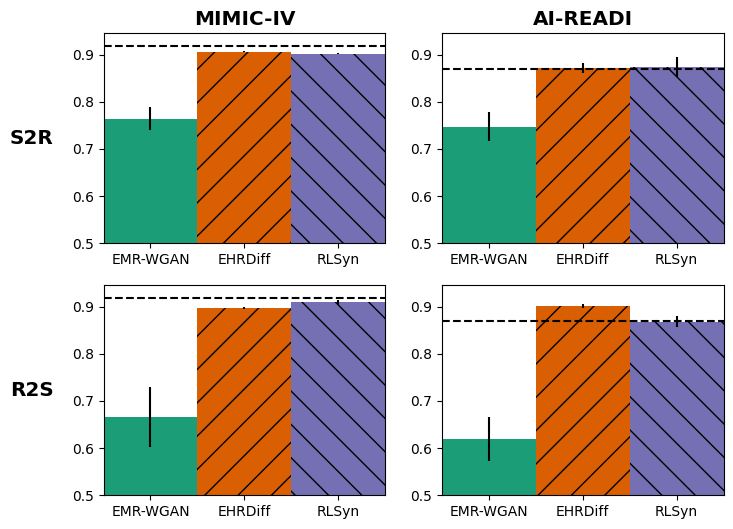

In [20]:
cmap = plt.colormaps.get('Dark2').colors
hatches = ['', '/' , '\\'] # List of hatches for each bar

plt.figure(figsize=(8,6))

for k, metric in enumerate(['S2R_AUC', 'R2S_AUC']):
    for i, dataset in enumerate(['MIMIC-IV', 'AI-READI']):
        mean_real = float(baseline.loc['Real Baseline', dataset].split(' ')[0])
        CI_real = float(baseline.loc['Real Baseline', dataset].split(' ')[2])

        print(dataset, metric)

        plt.subplot(2,2, i+1 + (2*k))
        vals = temp[[metric]].iloc[:, i]
        for j, (key,v) in enumerate(vals.items()):
            v = v.split(' ± ')
            plt.bar(j, float(v[0]), yerr=float(v[1]), width=1, label=key, color=cmap[j], hatch=hatches[j])
            
        plt.plot([-0.5, 2.5], [mean_real]*2, color='black', linestyle='--')
        #plt.fill_between([-0.5, 2.5], [mean_real-CI_real]*2, [mean_real+CI_real]*2, alpha=0.25, color='black')

        plt.xticks([0,1,2], vals.index)
        plt.ylim([0.5, 0.945])
        plt.xlim([-0.5, 2.5])
        if k == 0:
            plt.title(dataset, size='x-large', fontweight="bold")

        if i == 0:
            ax = plt.gca()
            ax.annotate(metric[0:3], xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0),
                    xycoords=ax.yaxis.label, textcoords='offset points',
                    size='x-large', ha='right', va='center', fontweight="bold")


plt.savefig('Classification_Perf.png', dpi=300, bbox_inches='tight')

In [13]:
vals.items()

## Fidelity Comparison

In [24]:
from sklearn.metrics import normalized_mutual_info_score

def latent_space_comp(synth, real, K, plot=False):

    if synth is None: 
        return np.nan
    
    larger_df = pd.concat([real, synth], axis=0)
    synth_id = [1]*len(real) + [0]*len(synth)


    # Fit KMeans
    scaler = StandardScaler()
    scaler.fit(real.values)
    X_scaled = scaler.transform(larger_df.values)

    pca = PCA(n_components=0.80)
    pca.fit(scaler.transform(real.values))
    X_pca = pca.transform(X_scaled)

    kmeans = KMeans(n_clusters=K, random_state=42, n_init='auto')
    kmeans.fit(X_pca)

    # Plot 1st 2 PCs
    if plot:
        plt.scatter([X_pca[i,0] for i in range(len(X_pca)) if synth_id[i] == 1], [X_pca[i,1] for i in range(len(X_pca)) if synth_id[i] == 1], c='r', alpha=0.2, label='Real')
        plt.scatter([X_pca[i,0] for i in range(len(X_pca)) if synth_id[i] == 0], [X_pca[i,1] for i in range(len(X_pca)) if synth_id[i] == 0], c='b', alpha=0.2, label='Synthetic', marker='s')
        plt.xlabel("PC 1")
        plt.ylabel("PC 2")
        plt.xticks([]) 
        plt.yticks([]) 
    # Metric
    return normalized_mutual_info_score(synth_id, kmeans.labels_)


# Create violin plot
def violin_plot(vals, title):
    
    filtered_data = [[val for val in sublist if np.isfinite(val)] for sublist in vals.T.values]

    plt.violinplot(filtered_data, showmeans=False, showmedians=True)

    # Set the labels and title
    plt.title(title)
    plt.xticks([1, 2, 3], ["EMR-WGAN", "EHRDiff", "RLSyn"])
    plt.ylim([-0.025 ,1])

In [25]:
from scipy.stats import wasserstein_distance

# Compute DWD on a single synthetic dataset
def compute_DWD(dataset, real, synth, modelname):
    
    if dataset == 'AI-READI':
        CAT_COLS = ['Age-related macular degeneration', 'Arthritis', 'Cancer', 'Cataracts (1+ eyes)', 'Chronic pullmonary problems', 'Circulation problems', 'Diabetic retinopathy (1+)', 'Digestive problems', 'Marijuana user', 'Dry eye (1+)', 'Glaucoma (1+)', 'Hearing impairment',
                        'Heart attack', 'High blood cholesterol', 'High blood pressure', 'Kidney problems', 'Low blood pressure', 'Mild cognitive impairmen', 'Multiple sclerosis', 'Obesity', 'Osteoporosis','Other heart issues (pacemaker)', 'Other neurological conditions',
                        "Parkinson's disease", 'Retinal vascular occlusion', 'Stroke', 'Type 2 Diabetes', 'Urinary problems', 
                        'ABNORMAL', 'BORDERLINE', 'NORMAL', 'OTHERWISE NORMAL', 'cube_visuospatial_executive_value', 'fluency_language_value', 'lettera_value', 'trails_visuospatial_executive_value'
                    ]
    else:
        CAT_COLS = ['WHITE', 'BLACK', 'ASIAN', 'HISPANIC', 'UN', 'OTHER', 'DIE_1y', 'GENDER', '008', '010', '031', '038', '041', '053', '054', '070', '070.4', '070.9', '071', '078', '079', '080', '081', '090', '10', '1000', '1001', '1002', '1004', '1005', '1006', '1007', '1008', '1009', '1010', '1011', '1013', '1014', '1015', '1019', '110', '110.1', '110.11', 
                    '110.12', '110.13', '110.2', '1100', '112', '112.3', '117', '117.4', '130', '130.1', '131', '132', '132.1', '133', '134', '134.1', '136', '145', '145.2', '145.3', '149', '149.1', '149.2', '149.3', '149.4', '149.9', '150', '151', '153', '153.2', '153.3', '155', '155.1', '157', '158', '159', '159.2', '159.3', '159.4', '164', '165', '165.1',
                    '170', '170.1', '170.2', '172', '172.11', '172.2', '172.3', '174', '174.1', '174.11', '175', '180', '180.1', '180.3', '182', '184', '184.1', '184.2', '185', '187', '187.2', '189', '189.2', '189.21', '189.4', '190', '191', '191.1', '191.11', '193', '194', '195', '195.1', '195.3', '196', '197', '198', '198.1', '198.2', '198.3', '198.4', '198.5', '198.6', 
                    '198.7', '199', '199.4', '200', '200.1', '201', '202', '202.2', '202.21', '202.24', '204', '204.1', '204.11', '204.12', '204.2', '204.21', '204.22', '204.3', '204.4', '208', '209', '210', '211', '212', '213', '214', '214.1', '215', '216', '217', '218', '218.1', '220', '221', '222', '223', '225', '225.1', '225.2', '226', '227', '227.1', '227.2', '227.3', 
                    '228', '229', '230', '240', '241', '241.1', '241.2', '242', '242.1', '242.2', '242.3', '244', '244.1', '244.2', '244.4', '244.5', '245', '245.21', '246', '246.7', '249', '250', '250.1', '250.11', '250.12', '250.13', '250.14', '250.2', '250.21', '250.22', '250.23', '250.24', '250.3', '250.4', '250.41', '250.42', '250.5', '251', '251.1', '251.8', '252', '252.1', 
                    '252.2', '253', '253.1', '253.11', '253.2', '253.3', '253.7', '254', '255', '255.11', '255.12', '255.21', '256', '256.4', '257', '257.1', '258', '259', '259.2', '260', '260.1', '260.6', '260.7', '261', '261.1', '261.2', '261.4', '261.41', '262', '263', '264', '269', '270', '270.1', '270.11', '270.2', '270.21', '270.31', '270.32', '270.33', '270.35', 
                    '271', '271.3', '271.9', '272', '272.1', '272.11', '272.12', '272.13', '274', '274.1', '274.11', '274.2', '274.21', '275', '275.1', '275.2', '275.3', '275.5', '275.53', '276', '276.1', '276.11', '276.12', '276.13', '276.14', '276.4', '276.41', '276.42', '276.6', '276.8', '277', '277.1', '277.4', '277.5', '277.51', '277.6', '277.7', '278', '278.1', '278.3', '278.4', 
                    '279', '279.1', '279.11', '279.7', '279.8', '280', '280.1', '280.2', '281', '281.1', '281.11', '281.12', '281.13', '281.9', '282', '282.5', '282.8', '282.9', '283', '283.1', '283.2', '283.21', '284', '285', '285.1', '285.2', '285.22', '285.8', '286', '286.1', '286.11', '286.12', '286.13', '286.2', '286.3', '286.4', '286.5', '286.6', '286.7', '287', '287.1', '287.2', 
                    '287.3', '287.31', '287.32', '287.4', '288', '288.1', '288.3', '289', '289.4', '289.5', '289.8', '289.9', '290', '290.1', '290.11', '290.16', '290.3', '291', '291.1', '291.4', '291.8', '292', '292.1', '292.12', '292.3', '292.4', '292.6', '293', '293.1', '295', '295.1', '295.2', '295.3', '296', '296.1', '296.2', '296.22', '297', '300', '300.1', '300.11', '300.12', '300.13', 
                    '300.3', '300.4', '300.8', '300.9', '301', '301.1', '301.2', '302', '303', '303.1', '303.3', '303.4', '304', '305.2', '305.21', '306', '306.1', '306.9', '31', '312', '312.3', '313', '313.1', '313.2', '313.3', '315', '315.1', '315.2', '315.3', '316', '316.1', '317', '317.1', '317.11', '318', '320', '323', '323.2', '323.8', '324', '325', '327', '327.3', '327.4', '327.41', '327.5', 
                    '327.6', '331', '331.1', '331.9', '332', '333', '333.1', '333.2', '333.3', '333.4', '333.8', '334', '334.1', '334.2', '335', '337', '337.1', '338', '339', '340', '340.1', '341', '342', '343', '344', '345', '345.1', '345.11', '345.12', '345.3', '346', '346.1', '346.2', '346.3', '347', '348', '348.2', '348.4', '348.7', '348.8', '348.9', '349', '350', '350.1', '350.2', '350.3', '350.5', '350.6', '351', '352', '352.1', '352.2', '353', '353.1', '353.2', '355', '355.1', '356', '357', '358', '358.1', '359', '359.1', '359.2', '360', '361', '362', '362.29', '362.4', '362.7', '362.8', '363', '364', '364.5', '364.9', '365', '365.11', '365.2', '366', '366.2', '367', '367.1', '367.4', '367.9', '368', '368.1', '368.2', '368.4', '368.5', '368.9', '369', '369.2', '369.5', '370', '370.1', '371', '371.1', '371.3', '372', '374', '374.1', '374.3', '375', '375.1', '376', '377', '377.3', '378', '378.1', '378.2', '378.5', '379', '379.1', '379.2', '379.4', '379.9', '38', '38.1', '38.2', '380', '380.1', '380.4', '381', '381.11', '381.2', '381.3', '382', '383', '384', '384.4', '385', '386', '386.1', '386.2', '386.21', '386.3', '386.9', '388', '389', '389.1', '389.2', '389.3', '389.4', '389.5', '394', '394.2', '394.3', '394.4', '394.7', '395', '395.1', '395.3', '395.4', '395.6', '396', '401', '401.1', '401.2', '401.21', '401.22', '401.3', '402', '41', '41.1', '41.2', '41.4', '411', '411.1', '411.2', '411.3', '411.4', '411.41', '411.8', '411.9', '414', '415', '415.11', '415.2', '415.21', '416', '418', '418.1', '420', '420.1', '420.2', '420.21', '420.22', '420.3', '425', '425.1', '425.11', '425.12', '425.2', '425.8', '426', '426.2', '426.21', '426.23', '426.24', '426.25', '426.3', '426.31', '426.32', '426.4', '426.8', '426.9', '426.91', '427', '427.1', '427.11', '427.12', '427.2', '427.3', '427.41', '427.42', '427.5', '427.6', '427.61', '427.7', '427.8', '427.9', '428', '428.2', '429', '429.1', '429.2', 
                    '429.3', '430', '430.1', '430.2', '430.3', '433', '433.1', '433.11', '433.12', '433.2', '433.21', '433.3', '433.31', '433.32', '433.5', '433.8', '440', '440.1', '440.2', '440.9', '441', '441.1', '441.2', '442', '442.1', '442.11', '442.2', '442.3', '442.8', '443', '443.1', '443.7', '443.8', '443.9', '444', '444.1', '444.2', '446', '446.3', '446.4', '446.5', '446.6', '446.7', '446.8', '446.9', '447', '447.1', '448', '450', '451', '451.2', '452', '452.1', '452.8', '454', '454.1', '454.11', '455', '456', '457', '458', '458.1', '458.2', '458.9', '459', '459.1', '459.9', '464', '465', '465.2', '465.4', '470', '471', '472', '473', '473.3', '473.4', '474', '474.1', '474.2', '475', '476', '477', '478', '479', '480', '480.1', '480.11', '480.12', '480.2', '480.3', '480.5', '481', '483', '495', '496', '496.1', '496.2', '496.21', '497', '498', '499', '500', '500.1', '500.2', '501', '502', '503', '504', '505', '506', '507', '508', '509', '509.1', '509.2', '509.3', '509.8', '510', '510.2', '512', '512.1', '512.2', '512.7', '512.8', '512.9', '513', '513.3', '513.4', '513.8', '514', '514.1', '514.2', '516', '516.1', '519', '519.1', '519.2', '519.8', '519.9', '520', '520.2', '521', '521.1', '522', '522.1', '522.5', '523', '523.1', '523.31', '523.32', '524', '525', '526', '527', '527.2', '527.7', '527.8', '528', '528.11', '528.12', '528.3', '528.5', '528.6', '528.7', '529', '529.1', '529.6', '53', '53.1', '530', '530.11', '530.12', '530.14', '530.2', '530.3', '530.5', '530.6', '530.7', '530.9', '531', '531.1', '531.2', '531.3', '531.4', '531.5', '532', '535', '535.1', '535.2', '535.6', '535.8', '536', '537', '539', '54', '540', '540.1', '540.11', '550', '550.1', '550.2', '550.3', '550.4', '550.5', '555', '555.1', '555.2', '555.21', '556', '556.1', '557', '557.1', '558', '559', '560', '560.1', '560.2', '560.3', '560.4', '561', '561.1', '562', '562.1', '563', '564', '564.1', '564.8', '564.9', '565', '565.1', '567', '568', '568.1', '569', '569.1', '569.2', '571', '571.5', '571.51', '571.6', '571.8', '571.81', '572', '573', '573.1', '573.2', '573.3', '573.4', '573.5', '573.6', '573.7', '573.9', '574', '574.1', '574.11', '574.12', '574.2', '574.3', '575', '575.1', '575.2', '575.6', '575.7', '575.8', '575.9', '577', '577.1', '577.2', '577.3', '578', '578.1', '578.2', '578.8', '578.9', '579', '579.2', '579.8', '580', '580.11', '580.12', '580.31', '580.32', '585', '585.1', '585.2', '585.3', '585.31', '586', '586.12', '586.2', '586.3', '586.4', '587', '588', '588.1', '589', '590', '591', '592', '592.1', '592.11', '592.12', '592.13', '592.2', '593', '593.2', '594', '594.1', '594.2', '594.3', '594.8', '595', '596', '596.1', '596.5', '597', '597.1', '597.2', '598', '598.9', '599', '599.1', '599.2', '599.3', '599.4', '599.6', '599.8', '599.9', '600', '601', '601.1', '601.11', '601.12', '601.4', '601.8', '602', '603', '603.1', '604', '604.1', '605', '608', '610', '610.1', '610.8', '611', '611.3', '612', '612.2', '613', '613.1', '613.5', '613.7', '613.8', '614', '614.1', '614.3', '614.31', '614.32', '614.33', '614.4', '614.5', '614.52', '614.53', '614.54', '615', '617', '618', '618.1', '618.2', '618.5', '618.6', '619', '619.1', '619.2', '619.3', '619.4', '619.5', '620', '621', '622', '622.1', '622.2', '623', '624', '624.1', '624.2', '624.9', '625', '625.1', '626', '626.1', '626.11', '626.12', '626.13', '626.14', '626.2', '626.8', '627', '627.1', '627.2', '627.3', '627.4', '627.5', '628', '634', '634.1', '634.3', '635', '635.2', '635.3', '636', '636.2', '636.3', '636.8', '639', '642', '642.1', '643', '643.1', '644', '645', '646', '647', '647.1', '647.3', '649', '649.1', '651', '652', '653', '654', '654.1', '654.2', '655', '656', '661', '663', '665', '668', '669', '671', '674', '676', '681', '681.1', '681.2', '681.3', '681.7', '686', '686.1', '686.2', '686.3', '686.4', '686.5', '687', '687.1', '687.2', '687.3', '687.4', '689', '690', '690.1', '691', '694', '694.1', '694.2', '694.3', '695', '695.1', '695.22', '695.3', '695.41', '695.42', '695.7', '695.8', '695.81', '695.9', '696', '696.41', '696.42', '697', '698', '70', '70.1', '70.2', '70.3', '70.4', '70.9', '700', '701', '701.2', '701.4', '701.5', '701.6', '702', '702.1', '703', '703.1', '704', '704.1', '704.11', '704.2', '704.8', '705', '705.3', '705.8', '706', '706.1', '706.2', '706.8', '707', '707.1', '709', '709.2', '709.3', '709.4', '709.5', '709.6', '709.7', '71', '710', '710.11', '710.12', '710.19', '711', '711.1', '711.2', '711.3', '712', '713', '713.5', '714', '714.1', '714.2', '715', '715.1', '716', '716.1', '716.2', '716.9', '717', '720', '721', '721.1', '721.2', '721.8', '722', '722.1', '722.6', '722.7', '722.8', '722.9', '723', '723.1', '724', '724.8', '724.9', '726', '726.1', '726.2', '726.3', '726.4', '727', '727.1', '727.2', '727.4', '727.5', '727.7', '728', '728.1', '728.2', '728.7', '728.71', '729', '729.3', '729.7', '731', '731.1', '732', '732.1', '733', '733.2', '733.4', '733.6', '733.8', '733.9', '735', '735.1', '735.2', '735.21', '735.3', '736', '736.2', '737', '737.1', '737.3', '738', '738.4', '739', '740', '740.1', '740.11', '740.12', '740.9', '741', '741.1', '741.2', '741.3', '741.4', '741.5', '742', '742.1', '742.2', '742.9', '743', '743.12', '743.13', '743.2', '743.21', '743.9', '745', '747', '747.1', '747.11', '747.12', '747.13', '747.2', '748', '749', '749.2', '750', '750.11', '750.14', '750.21', '750.22', '751', '751.11', '751.12', '751.2', '751.21', '751.22', '751.3', '752', '752.11', '752.2', '753', '754', '755', '755.1', '755.4', '755.6', '755.61', '756', '756.1', '756.21', '756.3', '756.5', '757', '758', '758.1', '759', '759.1', '760', '761', '763', '764', '765', '766', '770', '771', '771.1', '771.2', '772', '772.1', '772.2', '772.3', '772.4', '772.6', '773', '78', '780', '781', '782', '782.3', '782.6', '783', '785', '788', '789', '79', '79.1', '79.2', '790', '790.1', '790.6', '790.8', '790.9', '791', '792', '793', '793.2', '794', '795', '795.8', '796', '797', '797.1', '798', '8', '8.5', '8.52', '8.6', '8.7', '80', '800', '800.1', '800.2', '800.3', '800.4', '801', '801.1', '802', '803', '803.1', '803.2', '803.3', '804', '805', '807', '809', '81', '816', '817', '818', '819', '830', '835', '836', '840', '841', '842', '850', '851', '853', '854', '855', '856', '857', '858', '859', '860', '870', '870.1', '870.2', '870.3', '870.4', '870.5', '870.6', '870.8', '871', '871.3', '871.4', '872', '873', '874', '875', '876', '90', '90.2', '90.3', '907', '910', '911', '912', '913', '915', '916', '930', '931', '938', '938.1', '939', '941', '942', '946', '947', '949', '952', '958', '958.1', '958.2', '960', '960.1', '960.2', '961', '961.1', '962', '962.3', '963', '963.1', '964', '964.1', '965', '965.1', '965.3', '966', '967', '969', '971', '972', '973', '974', '975', '976', '977', 
                    '979', '980', '981', '983', '985', '987', '988', '989', '990', '994', '994.2'
                    ]
    if synth is not None:
        APDs = {col: np.abs(real[col].mean() - synth[col].mean()) for col in CAT_COLS}
        AWDs = {col: wasserstein_distance(real[col].values, synth[col].values) for col in real.columns if col not in CAT_COLS}
    else: 
        APDs = {col: np.nan for col in CAT_COLS}
        AWDs = {col: np.nan for col in real.columns if col not in CAT_COLS} 


    return pd.DataFrame(APDs, index=[modelname]), pd.DataFrame(AWDs, index=[modelname])

# Aggregate DWD over multiple datasets
def dimension_wise_diff(real, emr_synth, rl_synth, ehr_synth, dataset, only=None, real_test=None):
    # Aggregate DWD results
    temp = []
    for synth, modelname in [(emr_synth, 'EMR-WGAN'), (rl_synth, 'RLSyn'), (ehr_synth, 'EHRDiff')]:
        temp.append(compute_DWD(dataset, real, synth, modelname))

    if real_test is not None:
        temp.append(compute_DWD(dataset, real, real_test, 'Baseline'))


    # Normalize
    APDs = pd.concat([x[0] for x in temp])
    AWDs = pd.concat([x[1] for x in temp])

    if only is None:
        # Normalize & Sum
        AWDs /= AWDs.max()
        DWD = pd.concat([APDs, AWDs], axis=1).sum(axis=1)
    elif only == 'apd':
        DWD = APDs#.sum(axis=1)
    else:
        DWD = AWDs#.sum(axis=1)
    
    return DWD

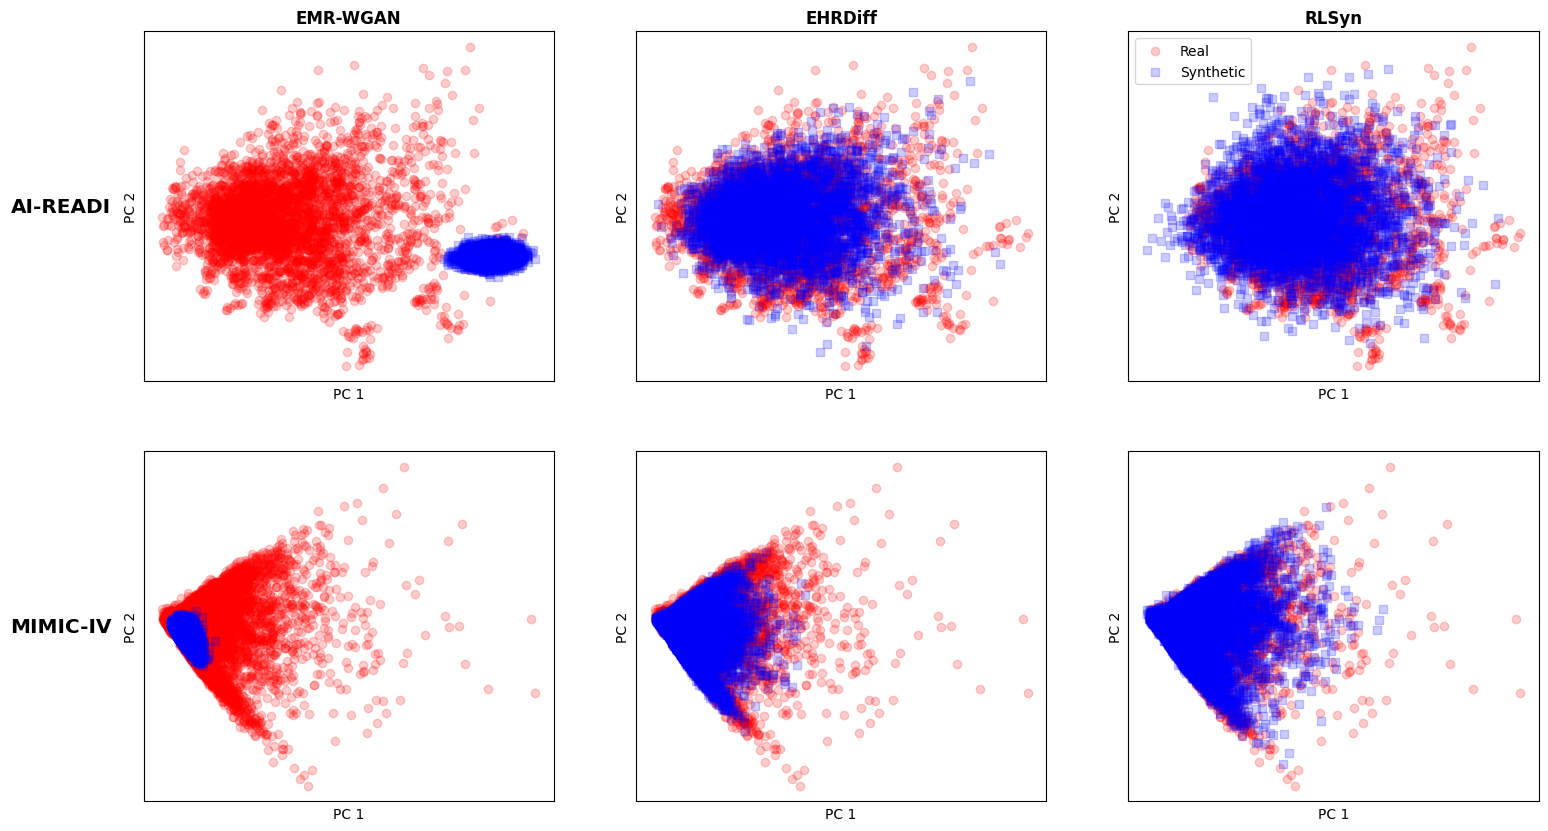

In [26]:
plt.figure(figsize=(18,10))


## AI-READI
#
#
#
#
base = os.path.join(data_path, 'AIREADI')

# To select best emrwgan checkpoint
emrwgan = pd.read_csv(os.path.join(base, 'EMR_WGAN_AIREADI', 'results_w_multiple_ckpts.csv'))
emrwgan = emrwgan.loc[emrwgan.groupby('tag')['s2h_auc'].idxmax()]

vals = {'EMR-WGAN': [], 'EHRDiff': [], 'RLSyn': []}
vals_DWD = {'EMR-WGAN': [], 'EHRDiff': [], 'RLSyn': []}
for i in range(10):
    real = pd.read_csv(f'/home/nick/rl_synth/AI-READI-FULL/preprocessed_data0.9_seed{i}/original_training_data.csv', index_col=None)

    # Synth Data
    if i != 9:
        ckpt = emrwgan.iloc[i]['checkpoint']
        emr_synth = pd.read_csv(os.path.join(base, 'EMR_WGAN_AIREADI','trial_9', f'seed{i}', f'ckpt_{ckpt}', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]
    else:
        emr_synth = None

    #rl_synth = pd.read_csv(os.path.join(base, 'RL_AIREADI', 'trial_9', f'seed{i}', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]
    rl_synth = pd.read_csv(os.path.join(base, 'RL_AIREADI', 'new_best', f'seed{i}', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]
    #ehr_synth = pd.read_csv(os.path.join(base, 'EHR_DIFF', 'trial_0_2500_epochs', f'trial_0_fewer_epochs_batch_seed0', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]
    ehr_synth = pd.read_csv(os.path.join(base, 'EHR_DIFF', 'EHR_DIFF_aireadi_best', 'EHR_DIFF_aireadi_best', f'trial_0_fewer_epochs_batch_seed0', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]
    
    if i == 0:
        plt.subplot(2,3,1)
        vals['EMR-WGAN'].append(latent_space_comp(emr_synth, real, 3, i == 0))
        plt.title('EMR-WGAN',fontweight="bold")
        ax = plt.gca()
        ax.annotate('AI-READI', xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='x-large', ha='right', va='center', fontweight="bold")

        plt.subplot(2,3,2)
        vals['EHRDiff'].append(latent_space_comp(ehr_synth, real, 3, i == 0))
        plt.title('EHRDiff',fontweight="bold")

        plt.subplot(2,3,3)
        vals['RLSyn'].append(latent_space_comp(rl_synth, real, 3, i == 0))
        plt.title('RLSyn',fontweight="bold")
        plt.legend()
    else: 
        vals['EMR-WGAN'].append(latent_space_comp(emr_synth, real, 3, i == 0))
        vals['EHRDiff'].append(latent_space_comp(ehr_synth, real, 3, i == 0))
        vals['RLSyn'].append(latent_space_comp(rl_synth, real, 3, i == 0))


    DWD = dimension_wise_diff(real, emr_synth, rl_synth, ehr_synth, dataset='AI-READI')

    for k in vals.keys():
        vals_DWD[k].append(DWD.loc[k])

DWD_AI_READI = pd.DataFrame(vals_DWD)
DWD_AI_READI.loc[9, 'EMR-WGAN'] = np.nan

vals_AI_READI = pd.DataFrame(vals)

## MIMIC
#
#
#
#
base = os.path.join(data_path, 'MIMIC')

# To select best EMRWGAN ckpts
emrwgan = pd.read_csv(os.path.join(base, 'EMR_WGAN_MIMIC', 'results.csv'))


vals = {'EMR-WGAN': [], 'EHRDiff': [], 'RLSyn': []}
vals_DWD = {'EMR-WGAN': [], 'EHRDiff': [], 'RLSyn': []}
for i in range(10):
    real = pd.read_csv(f'/data/nick/syn_mimic/preprocessing/test/original_training_data_0.csv').iloc[0:30000]

    # Synth Data
    ckpt = emrwgan.iloc[i]['tag'].split('ckpt_')[1]
    emr_synth = pd.read_csv(os.path.join(base, 'EMR_WGAN_MIMIC', f'seed{i}', f'ckpt_{ckpt}', 'synthetic_rescaled.csv'), index_col=0).iloc[0:30000]

    rl_synth = pd.read_csv(os.path.join(base, 'RL_MIMIC', f'seed{i}', 'synthetic_rescaled.csv'), index_col=0).iloc[0:30000]
    ehr_synth = pd.read_csv(os.path.join(base, 'EHR_DIFF_MIMIC', f'seed{i}', 'synthetic_rescaled.csv'), index_col=0).iloc[0:30000]


    if i == 0:
        plt.subplot(2,3,4)
        vals['EMR-WGAN'].append(latent_space_comp(emr_synth, real, 8, i == 0))
        ax = plt.gca()
        ax.annotate('MIMIC-IV', xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='x-large', ha='right', va='center', fontweight="bold")

        plt.subplot(2,3,5)
        vals['EHRDiff'].append(latent_space_comp(ehr_synth, real, 8, i == 0))
        
        plt.subplot(2,3,6)
        vals['RLSyn'].append(latent_space_comp(rl_synth, real, 8, i == 0))
        
    else: 
        vals['EMR-WGAN'].append(latent_space_comp(emr_synth, real, 8, i == 0))
        vals['EHRDiff'].append(latent_space_comp(ehr_synth, real, 8, i == 0))
        vals['RLSyn'].append(latent_space_comp(rl_synth, real, 8, i == 0))


        DWD = dimension_wise_diff(real, emr_synth, rl_synth, ehr_synth, dataset='MIMIC')

        for k in vals.keys():
            vals_DWD[k].append(DWD.loc[k])

DWD_MIMIC = pd.DataFrame(vals_DWD)

vals_MIMIC = pd.DataFrame(vals)

plt.savefig('PCA_figure.png', dpi=300, bbox_inches='tight')

In [27]:
## Table 3
# CWC & NMI
#
#
#
col1 = summarize_with_ci(df_mimic, 'cwc').set_index('tag')[['formatted']].rename(columns={'formatted':'CWC - MIMIC-IV'})
col2 = summarize_with_ci(df_aireadi, 'cwc').set_index('tag')[['formatted']].rename(columns={'formatted':'CWC - AI-READI'})
temp = pd.concat([col1, col2], axis=1)

# Add NMI
temp['NMI - MIMIC-IV'] = np.mean(vals_MIMIC).round(3).astype(str) + ' ± ' + (np.std(vals_MIMIC) * 1.96 / 3).round(3).astype(str)
temp['NMI - AI-READI'] = np.mean(vals_AI_READI).round(3).astype(str) + ' ± ' + (np.std(vals_AI_READI) * 1.96 / 3).round(3).astype(str)

# Add DWD
temp['DWD - AI-READI'] = np.mean(DWD_AI_READI).round(3).astype(str) + ' ± ' + (np.std(DWD_AI_READI) * 1.96 / 3).round(3).astype(str)
temp['DWD - MIMIC'] = np.mean(DWD_MIMIC).round(3).astype(str) + ' ± ' + (np.std(DWD_MIMIC) * 1.96 / 3).round(3).astype(str)

temp.loc[['EMR-WGAN', 'EHRDiff', 'RLSyn'], ['CWC - MIMIC-IV', 'NMI - MIMIC-IV', 'DWD - MIMIC', 'CWC - AI-READI', 'NMI - AI-READI', 'DWD - AI-READI']]

/home/nick/miniconda3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/home/nick/miniconda3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/home/nick/miniconda3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do no

,CWC - MIMIC-IV,NMI - MIMIC-IV,DWD - MIMIC,CWC - AI-READI,NMI - AI-READI,DWD - AI-READI
tag,,,,,,
EMR-WGAN,11.852 ± 0.045,0.108 ± 0.13,7.504 ± 0.602,1.352 ± 0.055,0.252 ± 0.003,34.187 ± 0.227
EHRDiff,7.848 ± 0.033,0.108 ± 0.0,7.504 ± 0.045,0.427 ± 0.007,0.252 ± 0.0,34.187 ± 10.989
RLSyn,8.877 ± 0.200,0.108 ± 0.0,7.504 ± 0.073,0.750 ± 0.015,0.252 ± 0.001,34.187 ± 8.325


In [28]:
from scipy.stats import wasserstein_distance

# Compute DWD on a single synthetic dataset
def make_biplot(dataset, real, synth, ax, ad2d):
    
    if dataset == 'AI-READI':
        CAT_COLS = ['Age-related macular degeneration', 'Arthritis', 'Cancer', 'Cataracts (1+ eyes)', 'Chronic pullmonary problems', 'Circulation problems', 'Diabetic retinopathy (1+)', 'Digestive problems', 'Marijuana user', 'Dry eye (1+)', 'Glaucoma (1+)', 'Hearing impairment',
                        'Heart attack', 'High blood cholesterol', 'High blood pressure', 'Kidney problems', 'Low blood pressure', 'Mild cognitive impairmen', 'Multiple sclerosis', 'Obesity', 'Osteoporosis','Other heart issues (pacemaker)', 'Other neurological conditions',
                        "Parkinson's disease", 'Retinal vascular occlusion', 'Stroke', 'Type 2 Diabetes', 'Urinary problems', 
                        'ABNORMAL', 'BORDERLINE', 'NORMAL', 'OTHERWISE NORMAL', 'cube_visuospatial_executive_value', 'fluency_language_value', 'lettera_value', 'trails_visuospatial_executive_value'
                    ]
    else:
        CAT_COLS = ['WHITE', 'BLACK', 'ASIAN', 'HISPANIC', 'UN', 'OTHER', 'DIE_1y', 'GENDER', '008', '010', '031', '038', '041', '053', '054', '070', '070.4', '070.9', '071', '078', '079', '080', '081', '090', '10', '1000', '1001', '1002', '1004', '1005', '1006', '1007', '1008', '1009', '1010', '1011', '1013', '1014', '1015', '1019', '110', '110.1', '110.11', 
                    '110.12', '110.13', '110.2', '1100', '112', '112.3', '117', '117.4', '130', '130.1', '131', '132', '132.1', '133', '134', '134.1', '136', '145', '145.2', '145.3', '149', '149.1', '149.2', '149.3', '149.4', '149.9', '150', '151', '153', '153.2', '153.3', '155', '155.1', '157', '158', '159', '159.2', '159.3', '159.4', '164', '165', '165.1',
                    '170', '170.1', '170.2', '172', '172.11', '172.2', '172.3', '174', '174.1', '174.11', '175', '180', '180.1', '180.3', '182', '184', '184.1', '184.2', '185', '187', '187.2', '189', '189.2', '189.21', '189.4', '190', '191', '191.1', '191.11', '193', '194', '195', '195.1', '195.3', '196', '197', '198', '198.1', '198.2', '198.3', '198.4', '198.5', '198.6', 
                    '198.7', '199', '199.4', '200', '200.1', '201', '202', '202.2', '202.21', '202.24', '204', '204.1', '204.11', '204.12', '204.2', '204.21', '204.22', '204.3', '204.4', '208', '209', '210', '211', '212', '213', '214', '214.1', '215', '216', '217', '218', '218.1', '220', '221', '222', '223', '225', '225.1', '225.2', '226', '227', '227.1', '227.2', '227.3', 
                    '228', '229', '230', '240', '241', '241.1', '241.2', '242', '242.1', '242.2', '242.3', '244', '244.1', '244.2', '244.4', '244.5', '245', '245.21', '246', '246.7', '249', '250', '250.1', '250.11', '250.12', '250.13', '250.14', '250.2', '250.21', '250.22', '250.23', '250.24', '250.3', '250.4', '250.41', '250.42', '250.5', '251', '251.1', '251.8', '252', '252.1', 
                    '252.2', '253', '253.1', '253.11', '253.2', '253.3', '253.7', '254', '255', '255.11', '255.12', '255.21', '256', '256.4', '257', '257.1', '258', '259', '259.2', '260', '260.1', '260.6', '260.7', '261', '261.1', '261.2', '261.4', '261.41', '262', '263', '264', '269', '270', '270.1', '270.11', '270.2', '270.21', '270.31', '270.32', '270.33', '270.35', 
                    '271', '271.3', '271.9', '272', '272.1', '272.11', '272.12', '272.13', '274', '274.1', '274.11', '274.2', '274.21', '275', '275.1', '275.2', '275.3', '275.5', '275.53', '276', '276.1', '276.11', '276.12', '276.13', '276.14', '276.4', '276.41', '276.42', '276.6', '276.8', '277', '277.1', '277.4', '277.5', '277.51', '277.6', '277.7', '278', '278.1', '278.3', '278.4', 
                    '279', '279.1', '279.11', '279.7', '279.8', '280', '280.1', '280.2', '281', '281.1', '281.11', '281.12', '281.13', '281.9', '282', '282.5', '282.8', '282.9', '283', '283.1', '283.2', '283.21', '284', '285', '285.1', '285.2', '285.22', '285.8', '286', '286.1', '286.11', '286.12', '286.13', '286.2', '286.3', '286.4', '286.5', '286.6', '286.7', '287', '287.1', '287.2', 
                    '287.3', '287.31', '287.32', '287.4', '288', '288.1', '288.3', '289', '289.4', '289.5', '289.8', '289.9', '290', '290.1', '290.11', '290.16', '290.3', '291', '291.1', '291.4', '291.8', '292', '292.1', '292.12', '292.3', '292.4', '292.6', '293', '293.1', '295', '295.1', '295.2', '295.3', '296', '296.1', '296.2', '296.22', '297', '300', '300.1', '300.11', '300.12', '300.13', 
                    '300.3', '300.4', '300.8', '300.9', '301', '301.1', '301.2', '302', '303', '303.1', '303.3', '303.4', '304', '305.2', '305.21', '306', '306.1', '306.9', '31', '312', '312.3', '313', '313.1', '313.2', '313.3', '315', '315.1', '315.2', '315.3', '316', '316.1', '317', '317.1', '317.11', '318', '320', '323', '323.2', '323.8', '324', '325', '327', '327.3', '327.4', '327.41', '327.5', 
                    '327.6', '331', '331.1', '331.9', '332', '333', '333.1', '333.2', '333.3', '333.4', '333.8', '334', '334.1', '334.2', '335', '337', '337.1', '338', '339', '340', '340.1', '341', '342', '343', '344', '345', '345.1', '345.11', '345.12', '345.3', '346', '346.1', '346.2', '346.3', '347', '348', '348.2', '348.4', '348.7', '348.8', '348.9', '349', '350', '350.1', '350.2', '350.3', '350.5', '350.6', '351', '352', '352.1', '352.2', '353', '353.1', '353.2', '355', '355.1', '356', '357', '358', '358.1', '359', '359.1', '359.2', '360', '361', '362', '362.29', '362.4', '362.7', '362.8', '363', '364', '364.5', '364.9', '365', '365.11', '365.2', '366', '366.2', '367', '367.1', '367.4', '367.9', '368', '368.1', '368.2', '368.4', '368.5', '368.9', '369', '369.2', '369.5', '370', '370.1', '371', '371.1', '371.3', '372', '374', '374.1', '374.3', '375', '375.1', '376', '377', '377.3', '378', '378.1', '378.2', '378.5', '379', '379.1', '379.2', '379.4', '379.9', '38', '38.1', '38.2', '380', '380.1', '380.4', '381', '381.11', '381.2', '381.3', '382', '383', '384', '384.4', '385', '386', '386.1', '386.2', '386.21', '386.3', '386.9', '388', '389', '389.1', '389.2', '389.3', '389.4', '389.5', '394', '394.2', '394.3', '394.4', '394.7', '395', '395.1', '395.3', '395.4', '395.6', '396', '401', '401.1', '401.2', '401.21', '401.22', '401.3', '402', '41', '41.1', '41.2', '41.4', '411', '411.1', '411.2', '411.3', '411.4', '411.41', '411.8', '411.9', '414', '415', '415.11', '415.2', '415.21', '416', '418', '418.1', '420', '420.1', '420.2', '420.21', '420.22', '420.3', '425', '425.1', '425.11', '425.12', '425.2', '425.8', '426', '426.2', '426.21', '426.23', '426.24', '426.25', '426.3', '426.31', '426.32', '426.4', '426.8', '426.9', '426.91', '427', '427.1', '427.11', '427.12', '427.2', '427.3', '427.41', '427.42', '427.5', '427.6', '427.61', '427.7', '427.8', '427.9', '428', '428.2', '429', '429.1', '429.2', 
                    '429.3', '430', '430.1', '430.2', '430.3', '433', '433.1', '433.11', '433.12', '433.2', '433.21', '433.3', '433.31', '433.32', '433.5', '433.8', '440', '440.1', '440.2', '440.9', '441', '441.1', '441.2', '442', '442.1', '442.11', '442.2', '442.3', '442.8', '443', '443.1', '443.7', '443.8', '443.9', '444', '444.1', '444.2', '446', '446.3', '446.4', '446.5', '446.6', '446.7', '446.8', '446.9', '447', '447.1', '448', '450', '451', '451.2', '452', '452.1', '452.8', '454', '454.1', '454.11', '455', '456', '457', '458', '458.1', '458.2', '458.9', '459', '459.1', '459.9', '464', '465', '465.2', '465.4', '470', '471', '472', '473', '473.3', '473.4', '474', '474.1', '474.2', '475', '476', '477', '478', '479', '480', '480.1', '480.11', '480.12', '480.2', '480.3', '480.5', '481', '483', '495', '496', '496.1', '496.2', '496.21', '497', '498', '499', '500', '500.1', '500.2', '501', '502', '503', '504', '505', '506', '507', '508', '509', '509.1', '509.2', '509.3', '509.8', '510', '510.2', '512', '512.1', '512.2', '512.7', '512.8', '512.9', '513', '513.3', '513.4', '513.8', '514', '514.1', '514.2', '516', '516.1', '519', '519.1', '519.2', '519.8', '519.9', '520', '520.2', '521', '521.1', '522', '522.1', '522.5', '523', '523.1', '523.31', '523.32', '524', '525', '526', '527', '527.2', '527.7', '527.8', '528', '528.11', '528.12', '528.3', '528.5', '528.6', '528.7', '529', '529.1', '529.6', '53', '53.1', '530', '530.11', '530.12', '530.14', '530.2', '530.3', '530.5', '530.6', '530.7', '530.9', '531', '531.1', '531.2', '531.3', '531.4', '531.5', '532', '535', '535.1', '535.2', '535.6', '535.8', '536', '537', '539', '54', '540', '540.1', '540.11', '550', '550.1', '550.2', '550.3', '550.4', '550.5', '555', '555.1', '555.2', '555.21', '556', '556.1', '557', '557.1', '558', '559', '560', '560.1', '560.2', '560.3', '560.4', '561', '561.1', '562', '562.1', '563', '564', '564.1', '564.8', '564.9', '565', '565.1', '567', '568', '568.1', '569', '569.1', '569.2', '571', '571.5', '571.51', '571.6', '571.8', '571.81', '572', '573', '573.1', '573.2', '573.3', '573.4', '573.5', '573.6', '573.7', '573.9', '574', '574.1', '574.11', '574.12', '574.2', '574.3', '575', '575.1', '575.2', '575.6', '575.7', '575.8', '575.9', '577', '577.1', '577.2', '577.3', '578', '578.1', '578.2', '578.8', '578.9', '579', '579.2', '579.8', '580', '580.11', '580.12', '580.31', '580.32', '585', '585.1', '585.2', '585.3', '585.31', '586', '586.12', '586.2', '586.3', '586.4', '587', '588', '588.1', '589', '590', '591', '592', '592.1', '592.11', '592.12', '592.13', '592.2', '593', '593.2', '594', '594.1', '594.2', '594.3', '594.8', '595', '596', '596.1', '596.5', '597', '597.1', '597.2', '598', '598.9', '599', '599.1', '599.2', '599.3', '599.4', '599.6', '599.8', '599.9', '600', '601', '601.1', '601.11', '601.12', '601.4', '601.8', '602', '603', '603.1', '604', '604.1', '605', '608', '610', '610.1', '610.8', '611', '611.3', '612', '612.2', '613', '613.1', '613.5', '613.7', '613.8', '614', '614.1', '614.3', '614.31', '614.32', '614.33', '614.4', '614.5', '614.52', '614.53', '614.54', '615', '617', '618', '618.1', '618.2', '618.5', '618.6', '619', '619.1', '619.2', '619.3', '619.4', '619.5', '620', '621', '622', '622.1', '622.2', '623', '624', '624.1', '624.2', '624.9', '625', '625.1', '626', '626.1', '626.11', '626.12', '626.13', '626.14', '626.2', '626.8', '627', '627.1', '627.2', '627.3', '627.4', '627.5', '628', '634', '634.1', '634.3', '635', '635.2', '635.3', '636', '636.2', '636.3', '636.8', '639', '642', '642.1', '643', '643.1', '644', '645', '646', '647', '647.1', '647.3', '649', '649.1', '651', '652', '653', '654', '654.1', '654.2', '655', '656', '661', '663', '665', '668', '669', '671', '674', '676', '681', '681.1', '681.2', '681.3', '681.7', '686', '686.1', '686.2', '686.3', '686.4', '686.5', '687', '687.1', '687.2', '687.3', '687.4', '689', '690', '690.1', '691', '694', '694.1', '694.2', '694.3', '695', '695.1', '695.22', '695.3', '695.41', '695.42', '695.7', '695.8', '695.81', '695.9', '696', '696.41', '696.42', '697', '698', '70', '70.1', '70.2', '70.3', '70.4', '70.9', '700', '701', '701.2', '701.4', '701.5', '701.6', '702', '702.1', '703', '703.1', '704', '704.1', '704.11', '704.2', '704.8', '705', '705.3', '705.8', '706', '706.1', '706.2', '706.8', '707', '707.1', '709', '709.2', '709.3', '709.4', '709.5', '709.6', '709.7', '71', '710', '710.11', '710.12', '710.19', '711', '711.1', '711.2', '711.3', '712', '713', '713.5', '714', '714.1', '714.2', '715', '715.1', '716', '716.1', '716.2', '716.9', '717', '720', '721', '721.1', '721.2', '721.8', '722', '722.1', '722.6', '722.7', '722.8', '722.9', '723', '723.1', '724', '724.8', '724.9', '726', '726.1', '726.2', '726.3', '726.4', '727', '727.1', '727.2', '727.4', '727.5', '727.7', '728', '728.1', '728.2', '728.7', '728.71', '729', '729.3', '729.7', '731', '731.1', '732', '732.1', '733', '733.2', '733.4', '733.6', '733.8', '733.9', '735', '735.1', '735.2', '735.21', '735.3', '736', '736.2', '737', '737.1', '737.3', '738', '738.4', '739', '740', '740.1', '740.11', '740.12', '740.9', '741', '741.1', '741.2', '741.3', '741.4', '741.5', '742', '742.1', '742.2', '742.9', '743', '743.12', '743.13', '743.2', '743.21', '743.9', '745', '747', '747.1', '747.11', '747.12', '747.13', '747.2', '748', '749', '749.2', '750', '750.11', '750.14', '750.21', '750.22', '751', '751.11', '751.12', '751.2', '751.21', '751.22', '751.3', '752', '752.11', '752.2', '753', '754', '755', '755.1', '755.4', '755.6', '755.61', '756', '756.1', '756.21', '756.3', '756.5', '757', '758', '758.1', '759', '759.1', '760', '761', '763', '764', '765', '766', '770', '771', '771.1', '771.2', '772', '772.1', '772.2', '772.3', '772.4', '772.6', '773', '78', '780', '781', '782', '782.3', '782.6', '783', '785', '788', '789', '79', '79.1', '79.2', '790', '790.1', '790.6', '790.8', '790.9', '791', '792', '793', '793.2', '794', '795', '795.8', '796', '797', '797.1', '798', '8', '8.5', '8.52', '8.6', '8.7', '80', '800', '800.1', '800.2', '800.3', '800.4', '801', '801.1', '802', '803', '803.1', '803.2', '803.3', '804', '805', '807', '809', '81', '816', '817', '818', '819', '830', '835', '836', '840', '841', '842', '850', '851', '853', '854', '855', '856', '857', '858', '859', '860', '870', '870.1', '870.2', '870.3', '870.4', '870.5', '870.6', '870.8', '871', '871.3', '871.4', '872', '873', '874', '875', '876', '90', '90.2', '90.3', '907', '910', '911', '912', '913', '915', '916', '930', '931', '938', '938.1', '939', '941', '942', '946', '947', '949', '952', '958', '958.1', '958.2', '960', '960.1', '960.2', '961', '961.1', '962', '962.3', '963', '963.1', '964', '964.1', '965', '965.1', '965.3', '966', '967', '969', '971', '972', '973', '974', '975', '976', '977', 
                    '979', '980', '981', '983', '985', '987', '988', '989', '990', '994', '994.2'
                    ]
    prev_real = [real[col].mean() for col in CAT_COLS]
    prev_synth = [synth[col].mean() for col in CAT_COLS]
    
    ax.scatter(prev_real, prev_synth, color='blue', alpha=0.5)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    #ax.set_title(f'{modelname}_{run}', fontsize = 12)
    ax.plot([0, 1], [0, 1], ls="--", c=".1")
    ax.text(0.5, 0.15,f'APD = {ad2d:.2f}')

    return


# Compute DWD on a single synthetic dataset
def make_histogram(real, synth, ax, ad2d, col, color):
    
    bins = ax.hist(real[col], edgecolor='black', color='white', density=True)
    ax.hist(synth[col], color=color, alpha=0.4, density=True, bins=bins[1])
    #ax.scatter(prev_real, prev_synth, color='blue', alpha=0.5)
        
    #if color == 'green':
    #    ax.text(0.5, 0.7, f'AWD = {ad2d:.2f}', transform=ax.transAxes)
    #elif color == 'orange':
    #    ax.text(0.5, 0.4, f'AWD = {ad2d:.2f}', transform=ax.transAxes)
    #else:
    ax.text(0.35, 0.6, f'AWD = {ad2d:.2f}', transform=ax.transAxes, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    return


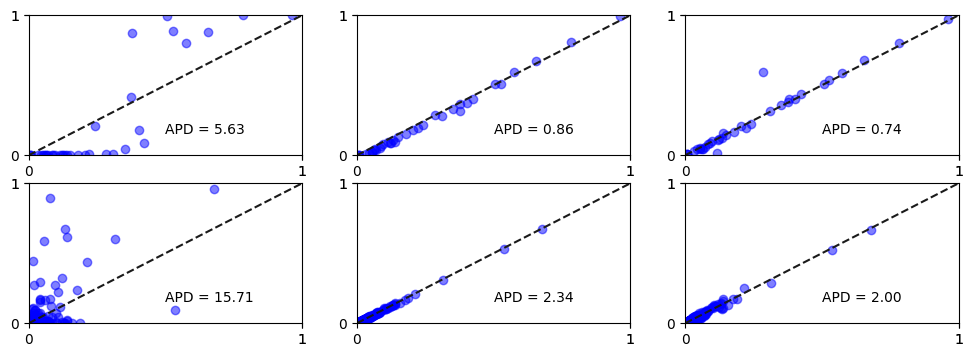

In [29]:
fig, axs = plt.subplots(2, 3, figsize = (12, 4))
plt.setp(axs, xticks=[0,1.0,1],
        yticks=[0, 1.0, 1])


## AI-READI
#
#
#
#
base = os.path.join(data_path, 'AIREADI')

# To select best emrwgan checkpoint
emrwgan = pd.read_csv(os.path.join(base, 'EMR_WGAN_AIREADI', 'results_w_multiple_ckpts.csv'))
emrwgan = emrwgan.loc[emrwgan.groupby('tag')['s2h_auc'].idxmax()]
    
real = pd.read_csv(f'/home/nick/rl_synth/AI-READI-FULL/preprocessed_data0.9_seed0/original_training_data.csv', index_col=None)
real_test = pd.read_csv(f'/home/nick/rl_synth/AI-READI-FULL/preprocessed_data0.9_seed0/original_testing_data.csv', index_col=None)

ckpt = emrwgan.iloc[0]['checkpoint']
emr_synth = pd.read_csv(os.path.join(base, 'EMR_WGAN_AIREADI','trial_9', f'seed0', f'ckpt_{ckpt}', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]

#rl_synth = pd.read_csv(os.path.join(base, 'RL_AIREADI', 'trial_9', f'seed0', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]
rl_synth = pd.read_csv(os.path.join(base, 'RL_AIREADI', 'new_best', f'seed{i}', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]
    
#ehr_synth = pd.read_csv(os.path.join(base, 'EHR_DIFF', 'trial_0_2500_epochs', f'trial_0_fewer_epochs_batch_seed0', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]
ehr_synth = pd.read_csv(os.path.join(base, 'EHR_DIFF', 'EHR_DIFF_aireadi_best', 'EHR_DIFF_aireadi_best', f'trial_0_fewer_epochs_batch_seed0', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]

APDs = dimension_wise_diff(real, emr_synth, rl_synth, ehr_synth, dataset='AI-READI', only='apd', real_test=real_test)

#make_biplot('AI-READI', real, real_test, axs[0,i], APDs.loc['Baseline'])
make_biplot('AI-READI', real, emr_synth, axs[0,0], APDs.loc['EMR-WGAN'].sum())
make_biplot('AI-READI', real, ehr_synth, axs[0,1], APDs.loc['EHRDiff'].sum())
make_biplot('AI-READI', real, rl_synth, axs[0,2], APDs.loc['RLSyn'].sum())
    
## MIMIC
#
#
#
#
base = os.path.join(data_path, 'MIMIC')

# To select best EMRWGAN ckpts
emrwgan = pd.read_csv(os.path.join(base, 'EMR_WGAN_MIMIC', 'results.csv'))

real = pd.read_csv(f'/data/nick/syn_mimic/preprocessing/test/original_training_data_0.csv').iloc[0:30000]

# Synth Data
ckpt = emrwgan.iloc[0]['tag'].split('ckpt_')[1]
emr_synth = pd.read_csv(os.path.join(base, 'EMR_WGAN_MIMIC', f'seed0', f'ckpt_{ckpt}', 'synthetic_rescaled.csv'), index_col=0).iloc[0:30000]

rl_synth = pd.read_csv(os.path.join(base, 'RL_MIMIC', f'seed0', 'synthetic_rescaled.csv'), index_col=0).iloc[0:30000]
ehr_synth = pd.read_csv(os.path.join(base, 'EHR_DIFF_MIMIC', f'seed0', 'synthetic_rescaled.csv'), index_col=0).iloc[0:30000]

APDs = dimension_wise_diff(real, emr_synth, rl_synth, ehr_synth, dataset='MIMIC', only='apd')

#make_biplot('MIMIC', real, real_test, axs[0,i], APDs.loc['Baseline'])
make_biplot('MIMIC', real, emr_synth, axs[1,0], APDs.loc['EMR-WGAN'].sum())
make_biplot('MIMIC', real, ehr_synth, axs[1,1], APDs.loc['EHRDiff'].sum())
make_biplot('MIMIC', real, rl_synth, axs[1,2], APDs.loc['RLSyn'].sum())

plt.savefig('biplots.png', dpi=300, bbox_inches='tight')

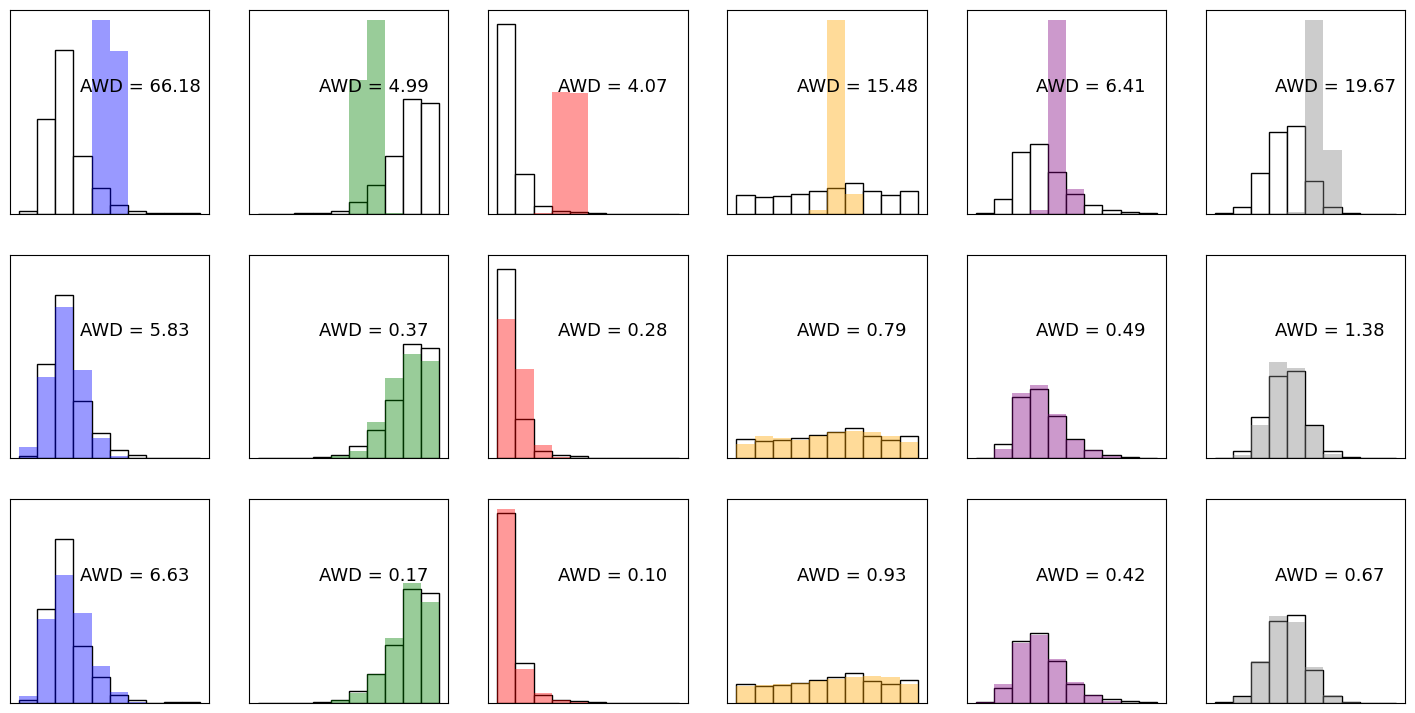

In [30]:
fig, axs = plt.subplots(3, 6, figsize = (18, 9))

#
#
#
base = os.path.join(data_path, 'AIREADI')

# To select best emrwgan checkpoint
emrwgan = pd.read_csv(os.path.join(base, 'EMR_WGAN_AIREADI', 'results_w_multiple_ckpts.csv'))
emrwgan = emrwgan.loc[emrwgan.groupby('tag')['s2h_auc'].idxmax()]

real = pd.read_csv(f'/home/nick/rl_synth/AI-READI-FULL/preprocessed_data0.9_seed0/original_training_data.csv', index_col=None)

ckpt = emrwgan.iloc[0]['checkpoint']
emr_synth = pd.read_csv(os.path.join(base, 'EMR_WGAN_AIREADI','trial_9', f'seed0', f'ckpt_{ckpt}', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]

#rl_synth = pd.read_csv(os.path.join(base, 'RL_AIREADI', 'trial_9', f'seed0', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]
rl_synth = pd.read_csv(os.path.join(base, 'RL_AIREADI', 'new_best', f'seed{i}', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]
    
#ehr_synth = pd.read_csv(os.path.join(base, 'EHR_DIFF', 'trial_0_2500_epochs', f'trial_0_fewer_epochs_batch_seed0', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]
ehr_synth = pd.read_csv(os.path.join(base, 'EHR_DIFF', 'EHR_DIFF_aireadi_best', 'EHR_DIFF_aireadi_best', f'trial_0_fewer_epochs_batch_seed0', 'synthetic_rescaled.csv'), index_col=0).iloc[0:4081]

AWDs = dimension_wise_diff(real, emr_synth, rl_synth, ehr_synth, dataset='AI-READI', only='awd')

colors = ['blue', 'green', 'red']

for i, col in enumerate(['blood_glucose_mean', 'act_sedentary_hrs', 'INSULIN (ng/mL)_value (ng/mL)']):
        
    make_histogram(real, emr_synth, axs[0,i], AWDs.loc['EMR-WGAN', col], col=col, color=colors[i])
    make_histogram(real, ehr_synth, axs[1,i], AWDs.loc['EHRDiff', col], col=col, color=colors[i])
    make_histogram(real, rl_synth, axs[2,i], AWDs.loc['RLSyn', col], col=col, color=colors[i])
    
    x_min, x_max = float('inf'), float('-inf')
    y_min, y_max = float('inf'), float('-inf')
    for ax in axs[:, i]:
        # Get the current limits
        current_xlim = ax.get_xlim()
        current_ylim = ax.get_ylim()
        
        # Update global limits
        x_min = min(x_min, current_xlim[0])
        x_max = max(x_max, current_xlim[1])
        y_min = min(y_min, current_ylim[0])
        y_max = max(y_max, current_ylim[1])

    for ax in axs[:, i]:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)


## MIMIC
#
#
#
#
base = os.path.join(data_path, 'MIMIC')

# To select best EMRWGAN ckpts
emrwgan = pd.read_csv(os.path.join(base, 'EMR_WGAN_MIMIC', 'results.csv'))

real = pd.read_csv(f'/data/nick/syn_mimic/preprocessing/test/original_training_data_0.csv').iloc[0:30000]

# Synth Data
ckpt = emrwgan.iloc[0]['tag'].split('ckpt_')[1]
emr_synth = pd.read_csv(os.path.join(base, 'EMR_WGAN_MIMIC', f'seed0', f'ckpt_{ckpt}', 'synthetic_rescaled.csv'), index_col=0).iloc[0:30000]
rl_synth = pd.read_csv(os.path.join(base, 'RL_MIMIC', f'seed0', 'synthetic_rescaled.csv'), index_col=0).iloc[0:30000]
ehr_synth = pd.read_csv(os.path.join(base, 'EHR_DIFF_MIMIC', f'seed0', 'synthetic_rescaled.csv'), index_col=0).iloc[0:30000]

AWDs = dimension_wise_diff(real, emr_synth, rl_synth, ehr_synth, dataset='MIMIC', only='awd')
colors = ['orange', 'purple', 'gray']
for i, col in enumerate(['AGE', 'BMI', 'DIASTOLIC']):
    
    make_histogram(real, emr_synth, axs[0,i+3], AWDs.loc['EMR-WGAN', col], col=col, color=colors[i])
    make_histogram(real, ehr_synth, axs[1,i+3], AWDs.loc['EHRDiff', col], col=col, color=colors[i])
    make_histogram(real, rl_synth, axs[2,i+3], AWDs.loc['RLSyn', col], col=col, color=colors[i])

    x_min, x_max = float('inf'), float('-inf')
    y_min, y_max = float('inf'), float('-inf')
    for ax in axs[:, i+3]:
        # Get the current limits
        current_xlim = ax.get_xlim()
        current_ylim = ax.get_ylim()
        
        # Update global limits
        x_min = min(x_min, current_xlim[0])
        x_max = max(x_max, current_xlim[1])
        y_min = min(y_min, current_ylim[0])
        y_max = max(y_max, current_ylim[1])

    for ax in axs[:, i+3]:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)


plt.savefig('Histograms.png', dpi=300, bbox_inches='tight')

In [31]:
real.columns.tolist()

['WHITE',
 'BLACK',
 'ASIAN',
 'HISPANIC',
 'UN',
 'OTHER',
 'DIE_1y',
 'GENDER',
 '008',
 '010',
 '031',
 '038',
 '041',
 '053',
 '054',
 '070',
 '070.4',
 '070.9',
 '071',
 '078',
 '079',
 '080',
 '081',
 '090',
 '10',
 '1000',
 '1001',
 '1002',
 '1004',
 '1005',
 '1006',
 '1007',
 '1008',
 '1009',
 '1010',
 '1011',
 '1013',
 '1014',
 '1015',
 '1019',
 '110',
 '110.1',
 '110.11',
 '110.12',
 '110.13',
 '110.2',
 '1100',
 '112',
 '112.3',
 '117',
 '117.4',
 '130',
 '130.1',
 '131',
 '132',
 '132.1',
 '133',
 '134',
 '134.1',
 '136',
 '145',
 '145.2',
 '145.3',
 '149',
 '149.1',
 '149.2',
 '149.3',
 '149.4',
 '149.9',
 '150',
 '151',
 '153',
 '153.2',
 '153.3',
 '155',
 '155.1',
 '157',
 '158',
 '159',
 '159.2',
 '159.3',
 '159.4',
 '164',
 '165',
 '165.1',
 '170',
 '170.1',
 '170.2',
 '172',
 '172.11',
 '172.2',
 '172.3',
 '174',
 '174.1',
 '174.11',
 '175',
 '180',
 '180.1',
 '180.3',
 '182',
 '184',
 '184.1',
 '184.2',
 '185',
 '187',
 '187.2',
 '189',
 '189.2',
 '189.21',
 '189.4',

## Privacy: main table (distance attack + DOMIAS)
Combines the nearest-neighbour distance attack (per-model `results.csv`) with DOMIAS (`results/domias/domias_per_run.csv`) and writes `paper/tables/privacy_results.tex`. Both are mean ± 95% CI over seeds.

In [ ]:
# Build the combined privacy table. Uses df_aireadi / df_mimic from the cells above.
domias = pd.read_csv(os.path.join(data_path, 'domias', 'domias_per_run.csv')).rename(columns={'model': 'tag'})
order = ['EMR-WGAN', 'CTAB-GAN+', 'EHRDiff', 'RLSyn']

def ci_col(df, value_col):
    return summarize_with_ci(df, value_col).set_index('tag')['formatted']

# Distance attack: add CTAB-GAN+ AI-READI from its own results.csv; CTAB-GAN+ MIMIC has no distance run.
ctab_ai = pd.read_csv(os.path.join(data_path, 'AIREADI', 'CTAB_GAN_aireadi', 'results.csv')); ctab_ai['tag'] = 'CTAB-GAN+'
dist_ai = ci_col(pd.concat([df_aireadi, ctab_ai]), 'synth_mem_auc')
dist_mi = ci_col(df_mimic, 'synth_mem_auc')
real_ai = ci_col(pd.concat([df_aireadi, ctab_ai]), 'real_mem_auc').iloc[0]
real_mi = ci_col(df_mimic, 'real_mem_auc').iloc[0]
dom_ai = ci_col(domias[domias.dataset == 'AI-READI'], 'domias_auc')
dom_mi = ci_col(domias[domias.dataset == 'MIMIC-IV'], 'domias_auc')

g = lambda s, m: s.get(m, '--')
rows = [('Real Data', real_mi, real_ai, '--', '--')]
for m in order:
    rows.append((m, g(dist_mi, m), g(dist_ai, m), g(dom_mi, m), g(dom_ai, m)))
privacy_table = pd.DataFrame(rows, columns=['Model', 'Dist MIMIC-IV', 'Dist AI-READI',
                                            'DOMIAS MIMIC-IV', 'DOMIAS AI-READI']).set_index('Model')
privacy_table

In [ ]:
# Paired comparison (same seed = same split) and vs-chance, for the DOMIAS columns.
for ds in ['AI-READI', 'MIMIC-IV']:
    piv = domias[domias.dataset == ds].pivot_table(index='seed', columns='tag', values='domias_auc')
    if {'RLSyn', 'EHRDiff'} <= set(piv.columns):
        d = piv[['RLSyn', 'EHRDiff']].dropna(); t = stats.ttest_rel(d['RLSyn'], d['EHRDiff'])
        print(f"{ds}: RLSyn - EHRDiff dAUC = {d['RLSyn'].mean() - d['EHRDiff'].mean():+.3f}, "
              f"paired t-test p = {t.pvalue:.3f} (n={len(d)})")
    for m in piv.columns:
        v = piv[m].dropna()
        if len(v) > 1:
            print(f"   {ds} {m}: {v.mean():.3f} vs chance(0.5) p = {stats.ttest_1samp(v, 0.5).pvalue:.3f}")

In [ ]:
# Write paper/tables/privacy_results.tex (DOMIAS columns marked with \new).
d = lambda x: str(x).replace(chr(177), r'$\pm$')
nw = lambda x: r'\new{' + d(x) + '}'
lines = [
    r'\begin{table}[h!]', r'    \centering',
    r'    \caption{Area under the receiver operating characteristic curve (AUC) of membership '
    r'inference attacks against synthetic data\new{, under the nearest-neighbour distance attack and '
    r'the DOMIAS attack} (mean $\pm$ 95\% confidence interval over seeds). AUC $\approx 0.5$ is random '
    r'chance; \emph{Real Data} is a positive control. \new{DOMIAS relies on density estimation, which '
    r'is uninformative on MIMIC-IV at its $1{,}486$ dimensions.}}',
    r'    \begin{tabular}{c|cc|cc}', r'        \toprule',
    r'         & \multicolumn{2}{c|}{\textbf{Distance attack}} & \multicolumn{2}{c}{\new{\textbf{DOMIAS}}} \\',
    r'         & \textbf{MIMIC-IV} & \textbf{AI-READI} & \new{\textbf{MIMIC-IV}} & \new{\textbf{AI-READI}} \\',
    r'        \cmidrule{1-5}',
]
rd = privacy_table.loc['Real Data']
lines.append('        Real Data & ' + d(rd.iloc[0]) + ' & ' + d(rd.iloc[1]) + ' & ' + nw(rd.iloc[2]) + ' & ' + nw(rd.iloc[3]) + r' \\')
lines.append(r'        \cmidrule{1-5}')
for m in order:
    nm = r'\modelname' if m == 'RLSyn' else m
    r_ = privacy_table.loc[m]
    lines.append('        ' + nm + ' & ' + d(r_.iloc[0]) + ' & ' + d(r_.iloc[1]) + ' & ' + nw(r_.iloc[2]) + ' & ' + nw(r_.iloc[3]) + r' \\')
lines += [r'        \bottomrule', r'    \end{tabular}', r'    \label{tab:privacy}', r'\end{table}']
tex = '\n'.join(lines)
with open(os.path.join(data_path, '..', 'paper', 'tables', 'privacy_results.tex'), 'w') as f:
    f.write(tex + '\n')
print(tex)